Imports.

In [ ]:
import os, zipfile, io, requests, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os, zipfile, requests, shutil

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
plt.rcParams['figure.dpi'] = 120


Using device: cuda


We are going to use gpu to make training faster.

Now, download the dataset using url and extract data. Follow the comments to understand the function of each block.

In [ ]:
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
root = "/content" if os.path.isdir("/content") else "."
zip_path = os.path.join(root, "UCI_HAR.zip")
data_dir = os.path.join(root, "UCI_HAR_Dataset")
tmp_extract_dir = os.path.join(root, "UCI_HAR_tmp") # Initial temporary extraction directory
final_dataset_extract_dir = os.path.join(root, "UCI_HAR_final_extract") # New temporary directory for the actual dataset content

if not os.path.exists(data_dir):
    print("Downloading UCI HAR dataset...")
    r = requests.get(URL, timeout=60)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        f.write(r.content)

    # Ensure tmp_extract_dir is clean and exists
    if os.path.exists(tmp_extract_dir):
        shutil.rmtree(tmp_extract_dir)
    os.makedirs(tmp_extract_dir)

    # Ensure final_dataset_extract_dir is clean and exists
    if os.path.exists(final_dataset_extract_dir):
        shutil.rmtree(final_dataset_extract_dir)
    os.makedirs(final_dataset_extract_dir)

    # First extraction: Extract the downloaded zip
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(tmp_extract_dir)

    inner_zip_path = os.path.join(tmp_extract_dir, "UCI HAR Dataset.zip")

    if os.path.exists(inner_zip_path):
        print("Found nested 'UCI HAR Dataset.zip'. Extracting second level...")
        with zipfile.ZipFile(inner_zip_path, "r") as inner_z:
            inner_z.extractall(final_dataset_extract_dir)
        # Now, the actual dataset content should be in final_dataset_extract_dir, and we search there
        search_dir = final_dataset_extract_dir
    else:
        # If no inner zip, the dataset content is directly in tmp_extract_dir
        search_dir = tmp_extract_dir

    extracted_contents = os.listdir(search_dir)
    dataset_source_path = None

    if "UCI HAR Dataset" in extracted_contents:
        candidate_path = os.path.join(search_dir, "UCI HAR Dataset")
        if os.path.isdir(candidate_path):
            dataset_source_path = candidate_path

    if dataset_source_path:
        # Move the dataset to its final location
        shutil.move(dataset_source_path, data_dir)
        # Verify it exists after move
        if not os.path.isdir(data_dir):
            raise FileNotFoundError(f"Failed to move dataset to '{data_dir}'. Destination not found after move operation.")
        print("Dataset ready at:", data_dir)
    else:
        raise FileNotFoundError(f"Could not locate the UCI HAR Dataset folder within '{search_dir}'. "
                                f"Contents found: {extracted_contents}")

    # Clean up temporary directories
    if os.path.exists(tmp_extract_dir):
        shutil.rmtree(tmp_extract_dir)
    if os.path.exists(final_dataset_extract_dir):
        shutil.rmtree(final_dataset_extract_dir)

else:
    print("Dataset already exists at:", data_dir)

classes = ["WALKING","WALKING_UPSTAIRS","WALKING_DOWNSTAIRS","SITTING","STANDING","LAYING"]
print("Classes:", classes)

Found nested 'UCI HAR Dataset.zip'. Extracting second level...
Dataset ready at: /content/UCI_HAR_Dataset
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


Now, we are going to prepare the data as per our need. The dataset gives separate train and test file for signals and labels.

In [ ]:
def _read_signals(folder):
    signal_names = [
        "body_acc_x_", "body_acc_y_", "body_acc_z_",
        "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
        "total_acc_x_", "total_acc_y_", "total_acc_z_",
    ]
    split = os.path.basename(folder)  # 'train' or 'test'
    all_signals = []
    for name in signal_names:
        path = os.path.join(folder, "Inertial Signals", name + split + ".txt")
        with open(path, 'r') as f:
            data = [list(map(float, line.strip().split())) for line in f]
        arr = np.asarray(data, dtype=np.float32)  # [N, 128]
        all_signals.append(arr[:, None, :])
    X = np.concatenate(all_signals, axis=1)  # [N, 9, 128]
    return X

def _read_labels(path):
    y = np.loadtxt(path, dtype=int) - 1  # 1..6 -> 0..5
    return y

train_dir = os.path.join(data_dir, "train")
test_dir  = os.path.join(data_dir, "test")

X_train = _read_signals(train_dir)
X_test  = _read_signals(test_dir)

y_train = _read_labels(os.path.join(train_dir, "y_train.txt"))
y_test  = _read_labels(os.path.join(test_dir, "y_test.txt"))

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((7352, 9, 128), (2947, 9, 128), (7352,), (2947,))

Plot one sample to visualize the signals of different channels. We are plotting three channels here for simplicity. You can plot other channels too.

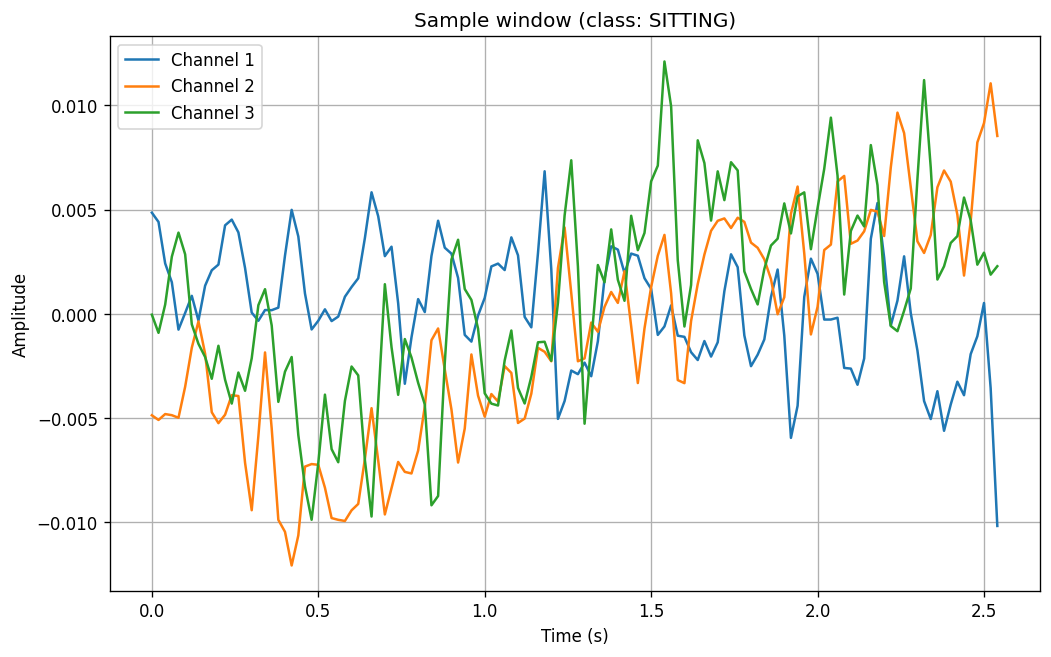

In [ ]:

sample_idx = 50
sig = X_train[sample_idx]  # [9, 128]
t = np.arange(sig.shape[1]) / 50.0  # 50Hz

plt.figure(figsize=(10,6))
for ch in range(3):  # first 3 channels
    plt.plot(t, sig[ch], label=f'Channel {ch+1}')
plt.title(f"Sample window (class: {classes[y_train[sample_idx]]})")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.legend(); plt.grid(True); plt.show()


How models take the data as input? Let's see.

In [ ]:
class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = HARDataset(X_train, y_train)
test_ds  = HARDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

len(train_ds), len(test_ds)


(7352, 2947)

The custom dataset class shows how the model will see one sample and the Dataloader function feeds mininatches to the model.

Let's define a CNN+Linear Model.

In [ ]:
class CNN1D(nn.Module):
    def __init__(self, in_ch=9, n_classes=6):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 128 -> 64
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 64 -> 32
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 32 -> 16
        )
        self.block4 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # -> [B, 128, 1]
        )
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = x.squeeze(-1)   # [B, 128]
        return self.fc(x)

model = CNN1D().to(device)
print(model)

CNN1D(
  (block1): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


Keep one thing in your mind. We need to have the model and data in the same device. 'cpu' or 'gpu'/'cuda'

Can you calculate the dimension after each block? That will be a task in your assignment.

How can we train our model? After random initialization, the model can make prediction. We calculate how far the model is from actual values with loss function and then update our model to minimize the loss value through the idea of gradient descent. After a few epochs, the model will learn to make better predictions. We can see the improvement by printing loss and accuracy value after each epoch. Validation loss and accuracy give us an idea how the model is generalizing i.e. how accurate its predictions are on unseen data.

## Cross-Entropy Loss

The cross-entropy loss for a single sample is defined as:



$
L = - \sum_{i=1}^{C} y_i \cdot \log(\hat{y}_i)
$



Where:
- C= number of classes  
- $y_i$ = true label (one-hot encoded; 1 if class i is correct, else 0)  
- $\hat{y}_i$ = predicted probability for class i (from softmax output)  

- If the true class is k, then only $y_k = 1$, so the loss simplifies to:


$
         L = - \log(\hat{y}_k)
$



- For a dataset of N samples, the average cross-entropy loss is:



$
L = - \frac{1}{N} \sum_{j=1}^{N} \sum_{i=1}^{C} y_{j,i} \cdot \log(\hat{y}_{j,i})
$




In [ ]:
def accuracy(pred, target):
    return (pred.argmax(1) == target).float().mean().item()

def evaluate(loader):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0

    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out = model(Xb)
            loss = F.cross_entropy(out, yb)
            total_loss += loss.item() * Xb.size(0)
            total_acc  += (out.argmax(1) == yb).sum().item()
            n += Xb.size(0)

    return total_loss/n, total_acc/n

opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
epochs = 12
train_hist, val_hist = [], []

for ep in range(1, epochs+1):
    model.train()
    tot, n = 0.0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        out = model(Xb)
        loss = F.cross_entropy(out, yb)
        loss.backward()
        opt.step()
        tot += loss.item() * Xb.size(0); n += Xb.size(0)
    tr_loss = tot/n
    tr_acc  = evaluate(train_loader)[1]
    va_loss, va_acc = evaluate(test_loader)  # using test as validation for simplicity
    train_hist.append((tr_loss, tr_acc)); val_hist.append((va_loss, va_acc))
    print(f"Epoch {ep:02d}: train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | val_loss={va_loss:.4f} val_acc={va_acc:.3f}")


Epoch 01: train_loss=0.9876 train_acc=0.803 | val_loss=0.6707 val_acc=0.731
Epoch 02: train_loss=0.3791 train_acc=0.906 | val_loss=0.4404 val_acc=0.844
Epoch 03: train_loss=0.2356 train_acc=0.917 | val_loss=0.3426 val_acc=0.877
Epoch 04: train_loss=0.1665 train_acc=0.923 | val_loss=0.3273 val_acc=0.874
Epoch 05: train_loss=0.1505 train_acc=0.940 | val_loss=0.2692 val_acc=0.892
Epoch 06: train_loss=0.1287 train_acc=0.952 | val_loss=0.2749 val_acc=0.896
Epoch 07: train_loss=0.1304 train_acc=0.943 | val_loss=0.2924 val_acc=0.889
Epoch 08: train_loss=0.1164 train_acc=0.951 | val_loss=0.3032 val_acc=0.905
Epoch 09: train_loss=0.1218 train_acc=0.945 | val_loss=0.3125 val_acc=0.891
Epoch 10: train_loss=0.1151 train_acc=0.947 | val_loss=0.3061 val_acc=0.895
Epoch 11: train_loss=0.1142 train_acc=0.948 | val_loss=0.3025 val_acc=0.898
Epoch 12: train_loss=0.1100 train_acc=0.944 | val_loss=0.3363 val_acc=0.892


In model training tasks, it is almost customary to have a loss vs epoch plot. We can confirm if the model is overfitting or not.

***Remember what overfitting is.***

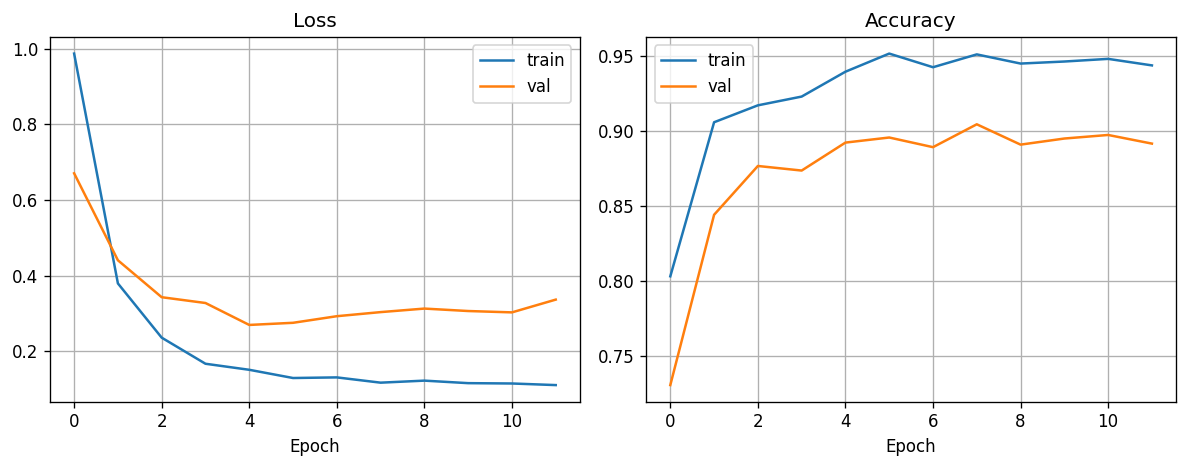

In [ ]:
tr_loss = [x[0] for x in train_hist]
tr_acc  = [x[1] for x in train_hist]
va_loss = [x[0] for x in val_hist]
va_acc  = [x[1] for x in val_hist]

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(tr_loss, label='train'); ax[0].plot(va_loss, label='val')
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(tr_acc, label='train'); ax[1].plot(va_acc, label='val')
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()


Do you think training for more epochs will help?

### Model Evaluation using Confusion Matrix and Classification Report

The **confusion matrix** is a useful visualization to understand how well the model performs across different activity classes.  
It summarizes the **correct predictions (diagonal elements)** and **misclassifications (off-diagonal elements)** made by the model for each class.


The **classification report** complements the confusion matrix by providing three key metrics for each class:

$
\text{Precision} = \frac{TP}{TP + FP}$


$\text{Recall} = \frac{TP}{TP + FN}$

$
\text{F1-score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$

Where:
- **TP** = True Positives (correctly predicted class samples)  
- **FP** = False Positives (incorrectly predicted as this class)  
- **FN** = False Negatives (missed samples of this class)

A high **F1-score** indicates both high precision and high recall, meaning the model performs consistently well for that class.


                    precision    recall  f1-score   support

           WALKING     0.9800    0.8891    0.9323       496
  WALKING_UPSTAIRS     0.8590    0.9703    0.9113       471
WALKING_DOWNSTAIRS     0.9480    0.9548    0.9514       420
           SITTING     0.8289    0.6904    0.7533       491
          STANDING     0.7705    0.9023    0.8312       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.8918      2947
         macro avg     0.8977    0.8928    0.8923      2947
      weighted avg     0.8967    0.8918    0.8912      2947



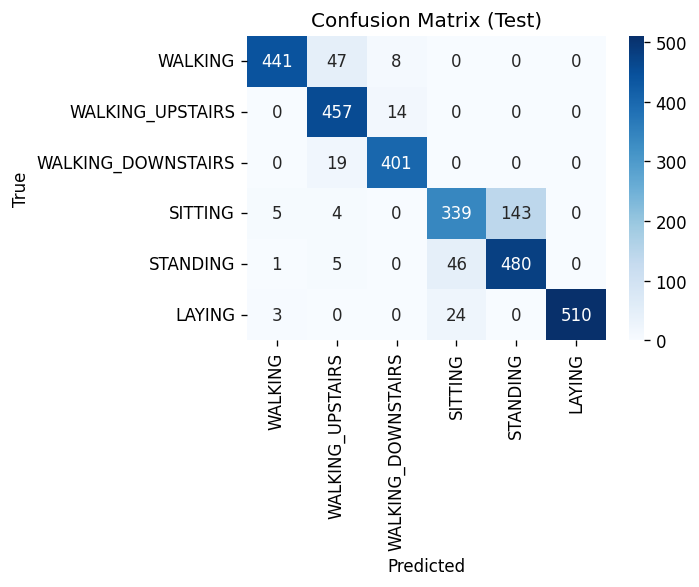

In [ ]:
def predict_all(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            out = model(Xb)
            preds.append(out.argmax(1).cpu().numpy())
            # The classification report and confusion matrix can work only on
            # numpy arrays that are in cpu, so we have to move tensors to cpu.
            labels.append(yb.numpy())

    return np.concatenate(preds), np.concatenate(labels)

y_pred, y_true = predict_all(test_loader)

print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Test)"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


Congo!The model is working pretty well!